# 02. JEPX 東京エリア価格 - day-ahead 予測モデル

`01.data_transformation.ipynb` で生成した特徴量 (`data/jepx_tokyo_features.parquet`) を使い、当日までの確定データから **翌日 24 時間 = 48 コマ** の東京エリア価格を一括予測するモデルを学習・評価する。

## モデル一覧
- **Seasonal-naive D-7** (ベースライン)
- **LightGBM raw** (MSE): 標準ベースライン
- **LightGBM log1p**: テール圧縮
- **LightGBM quantile p50**: pinball loss、MAE 直接最適化
- **LightGBM Huber**: 外れ値頑健
- **★ LightGBM q50 on `target_dev_prev_day` (現メイン)**: 03 分析で test MAE 最小。`target − prev_day_mean` を学習し `prev_day_mean` を足して raw に戻す。
- **Ensemble (単純平均 / val 最適化)**: 上記 LightGBM 5 モデルの組み合わせ

## 評価
- 時系列 hold-out: 末尾 6 ヶ月を test、その前 3 ヶ月を val、それ以前を train
- 指標: RMSE / MAE / sMAPE

**注意**: 03 の分析で val 期間 (2025-08-2025-11) が穏やかすぎて test 分布をカバーしていないことが判明。val 最適化アンサンブル重みは慎重に解釈。

## 出力 (すべて `data/` 配下)
- `model_lgbm.joblib` … 5 LightGBM モデル + ensemble 重みの artifact
- `predictions_test.parquet` … test 期間の実測値・各モデル予測値
- `metrics_summary.csv` … モデル × split × 指標の集計表


## ライブラリ


In [1]:
from __future__ import annotations

import json
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401  matplotlib の日本語フォントを有効化
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb
from scipy.optimize import minimize

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 50)
sns.set_theme(style="whitegrid", font="IPAexGothic")


## パラメータ / パス


In [2]:
BASE_DIR_CANDIDATES = [
    Path.cwd(),
    Path.cwd() / "blog" / "06.JEPX_estimation",
    Path("/home/kohei/WorkSpace/blog/06.JEPX_estimation"),
]
BASE_DIR = next((p for p in BASE_DIR_CANDIDATES if (p / "data" / "jepx_tokyo_features.parquet").exists()), None)
if BASE_DIR is None:
    raise FileNotFoundError("data/jepx_tokyo_features.parquet が見つかりません。01.data_transformation.ipynb を先に実行してください。")

DATA_DIR = BASE_DIR / "data"
FEATURES_PARQUET  = DATA_DIR / "jepx_tokyo_features.parquet"
FEATURE_META_JSON = DATA_DIR / "feature_metadata.json"
MODEL_PATH        = DATA_DIR / "model_lgbm.joblib"
PRED_PATH         = DATA_DIR / "predictions_test.parquet"
METRICS_PATH      = DATA_DIR / "metrics_summary.csv"

# 時系列 hold-out 設定
TEST_MONTHS = 6
VAL_MONTHS = 3

# LightGBM ハイパラ
LGBM_PARAMS = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.02,
    "num_leaves": 63,
    "max_depth": -1,
    "min_data_in_leaf": 200,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "lambda_l2": 1.0,
    "verbose": -1,
}
N_ESTIMATORS = 5000
EARLY_STOPPING_ROUNDS = 100

RIDGE_ALPHA = 1.0
RANDOM_SEED = 42

print("BASE_DIR :", BASE_DIR)


BASE_DIR : /home/kohei/WorkSpace/blog/06.JEPX_estimation


## データロード


In [3]:
feature_df = pd.read_parquet(FEATURES_PARQUET)
meta = json.loads(FEATURE_META_JSON.read_text(encoding="utf-8"))

cal_cols     = meta["calendar_cols"]
weather_cols = meta["weather_cols"]
lag_cols     = meta["lag_cols"]
feature_cols = cal_cols + weather_cols + lag_cols

# メタ情報と DataFrame の整合性チェック
missing = [c for c in feature_cols + ["target"] if c not in feature_df.columns]
assert not missing, f"feature_df に欠落している列: {missing}"

print("shape       :", feature_df.shape)
print("period      :", feature_df.index.min(), "->", feature_df.index.max())
print("feature cnt :", len(feature_cols))
print("target NaN  :", feature_df["target"].isna().sum())
display(feature_df[["target"] + feature_cols].describe().T.head(20))


shape       : (107472, 38)
period      : 2020-04-08 00:00:00 -> 2026-05-25 23:30:00
feature cnt : 25
target NaN  : 0


,count,mean,std,min,25%,50%,75%,max
target,107472.0,14.803143,13.334163,0.010000,8.790000,12.200000,17.220000,252.000000
hour,107472.0,11.500000,6.922219,0.000000,5.750000,11.500000,17.250000,23.000000
minute,107472.0,15.000000,15.000070,0.000000,0.000000,15.000000,30.000000,30.000000
dayofweek,107472.0,3.000893,2.000009,0.000000,1.000000,3.000000,5.000000,6.000000
month,107472.0,6.481018,3.424369,1.000000,4.000000,6.000000,9.000000,12.000000
day,107472.0,15.729790,8.774153,1.000000,8.000000,16.000000,23.000000,31.000000
is_weekend,107472.0,0.285842,0.451817,0.000000,0.000000,0.000000,1.000000,1.000000
is_holiday,107472.0,0.050022,0.217992,0.000000,0.000000,0.000000,0.000000,1.000000
is_dayoff,107472.0,0.326932,0.469094,0.000000,0.000000,0.000000,1.000000,1.000000
temperature_2m,107472.0,16.208759,8.926609,-7.700000,9.000000,16.500000,23.500000,39.300000


## 時系列 hold-out 分割


In [4]:
last_ts = feature_df.index.max()
test_start = (last_ts - pd.DateOffset(months=TEST_MONTHS)).normalize()
val_start  = (test_start - pd.DateOffset(months=VAL_MONTHS)).normalize()

train_df = feature_df.loc[: val_start - pd.Timedelta("30min")]
val_df   = feature_df.loc[val_start: test_start - pd.Timedelta("30min")]
test_df  = feature_df.loc[test_start:]

split_summary = pd.DataFrame(
    {
        "rows":  [len(train_df), len(val_df), len(test_df)],
        "start": [train_df.index.min(), val_df.index.min(), test_df.index.min()],
        "end":   [train_df.index.max(), val_df.index.max(), test_df.index.max()],
    },
    index=["train", "val", "test"],
)
display(split_summary)

# 連続性・時系列性の確認
assert len(train_df) + len(val_df) + len(test_df) == len(feature_df), "行数の合計が一致しません"
assert train_df.index.max() < val_df.index.min() < test_df.index.min(), "時系列順が崩れています"

X_train, y_train = train_df[feature_cols], train_df["target"]
X_val,   y_val   = val_df[feature_cols],   val_df["target"]
X_test,  y_test  = test_df[feature_cols],  test_df["target"]


,rows,start,end
train,94320,2020-04-08,2025-08-24 23:30:00
val,4416,2025-08-25,2025-11-24 23:30:00
test,8736,2025-11-25,2026-05-25 23:30:00


## 評価ヘルパ

RMSE / MAE / sMAPE を返す。sMAPE は target=0 で破綻しないよう分母に小さな ε を加えた安全版。


In [5]:
def smape(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-3) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred) + eps)
    return float(np.mean(200.0 * np.abs(y_pred - y_true) / denom))


def evaluate(y_true: pd.Series, y_pred: pd.Series, model: str, split: str) -> dict:
    # NaN を除外して評価 (seasonal-naive は冒頭で NaN が出るため)
    mask = (~y_true.isna()) & (~y_pred.isna())
    yt, yp = y_true[mask].to_numpy(), y_pred[mask].to_numpy()
    return {
        "model": model,
        "split": split,
        "n":     int(mask.sum()),
        "rmse":  float(np.sqrt(mean_squared_error(yt, yp))),
        "mae":   float(mean_absolute_error(yt, yp)),
        "smape": smape(yt, yp),
    }


metrics_rows: list[dict] = []


## ベースライン: Seasonal-naive (D-7 同スロット)

前処理で作っておいた `lag_7d_same_slot` (7 日前同スロットの実測値) をそのまま予測値とする。


In [6]:
y_pred_naive_val  = val_df["lag_7d_same_slot"]
y_pred_naive_test = test_df["lag_7d_same_slot"]

metrics_rows.append(evaluate(y_val,  y_pred_naive_val,  "seasonal_naive_d7", "val"))
metrics_rows.append(evaluate(y_test, y_pred_naive_test, "seasonal_naive_d7", "test"))
display(pd.DataFrame(metrics_rows))


,model,split,n,rmse,mae,smape
0,seasonal_naive_d7,val,4416,3.038855,1.748922,12.501014
1,seasonal_naive_d7,test,8736,5.877800,3.389243,26.751149


## メインモデル: LightGBM

`lgb.train` + early stopping（val RMSE が改善しなくなった時点で止める）。


In [7]:
train_ds = lgb.Dataset(X_train, label=y_train, feature_name=feature_cols)
val_ds   = lgb.Dataset(X_val,   label=y_val,   feature_name=feature_cols, reference=train_ds)

lgbm_model = lgb.train(
    {**LGBM_PARAMS, "seed": RANDOM_SEED},
    train_ds,
    num_boost_round=N_ESTIMATORS,
    valid_sets=[train_ds, val_ds],
    valid_names=["train", "val"],
    callbacks=[
        lgb.early_stopping(EARLY_STOPPING_ROUNDS),
        lgb.log_evaluation(period=100),
    ],
)

print("best_iteration:", lgbm_model.best_iteration)
assert lgbm_model.best_iteration < N_ESTIMATORS, "早期終了が効いていません。N_ESTIMATORS を増やしてください。"

y_pred_lgbm_val  = pd.Series(lgbm_model.predict(X_val,  num_iteration=lgbm_model.best_iteration), index=val_df.index)
y_pred_lgbm_test = pd.Series(lgbm_model.predict(X_test, num_iteration=lgbm_model.best_iteration), index=test_df.index)

metrics_rows.append(evaluate(y_val,  y_pred_lgbm_val,  "lightgbm", "val"))
metrics_rows.append(evaluate(y_test, y_pred_lgbm_test, "lightgbm", "test"))


Training until validation scores don't improve for 100 rounds
[100]	train's rmse: 6.43444	val's rmse: 2.24196
[200]	train's rmse: 5.38822	val's rmse: 2.10361
[300]	train's rmse: 4.96878	val's rmse: 2.08198
[400]	train's rmse: 4.69208	val's rmse: 2.08648
Early stopping, best iteration is:
[355]	train's rmse: 4.81657	val's rmse: 2.07575
best_iteration: 355


## LightGBM (log1p ターゲット変換)

目的変数を `np.log1p(target - target_min + 1)` で変換して学習する版。  
JEPX 価格はテール (ピーク 100 円超、谷 0 円付近) が長く、生の MSE はピーク帯に学習を引っ張られやすい。  
log 変換でテールを圧縮することで、谷・通常帯・ピーク帯の相対重みを均す。  
予測時は `np.expm1` で元スケールへ戻す。


In [8]:
# 目的変数の log 変換: 負値があっても安全になるようオフセットを付ける
TARGET_OFFSET = max(0.0, -float(y_train.min())) + 1.0
y_train_log = np.log1p(y_train + TARGET_OFFSET)
y_val_log   = np.log1p(y_val   + TARGET_OFFSET)

train_ds_log = lgb.Dataset(X_train, label=y_train_log, feature_name=feature_cols)
val_ds_log   = lgb.Dataset(X_val,   label=y_val_log,   feature_name=feature_cols, reference=train_ds_log)

lgbm_model_log = lgb.train(
    {**LGBM_PARAMS, "seed": RANDOM_SEED},
    train_ds_log,
    num_boost_round=N_ESTIMATORS,
    valid_sets=[train_ds_log, val_ds_log],
    valid_names=["train", "val"],
    callbacks=[
        lgb.early_stopping(EARLY_STOPPING_ROUNDS),
        lgb.log_evaluation(period=100),
    ],
)
print("best_iteration (log1p):", lgbm_model_log.best_iteration)

# log スケールで予測してから元スケールへ
def _predict_log_back(model, X):
    return np.expm1(model.predict(X, num_iteration=model.best_iteration)) - TARGET_OFFSET

y_pred_lgbm_log_val  = pd.Series(_predict_log_back(lgbm_model_log, X_val),  index=val_df.index)
y_pred_lgbm_log_test = pd.Series(_predict_log_back(lgbm_model_log, X_test), index=test_df.index)

metrics_rows.append(evaluate(y_val,  y_pred_lgbm_log_val,  "lightgbm_log1p", "val"))
metrics_rows.append(evaluate(y_test, y_pred_lgbm_log_test, "lightgbm_log1p", "test"))


Training until validation scores don't improve for 100 rounds
[100]	train's rmse: 0.2565	val's rmse: 0.121406
[200]	train's rmse: 0.211109	val's rmse: 0.125146
Early stopping, best iteration is:
[114]	train's rmse: 0.246181	val's rmse: 0.121319
best_iteration (log1p): 114


## LightGBM (quantile p50, pinball loss)

`objective="quantile"`, `alpha=0.5` で中央値を学習。pinball loss は **MAE を直接最適化** するため、外れ値に引きずられにくく安定した予測になる。

In [9]:
lgbm_q50_params = {**LGBM_PARAMS, "objective": "quantile", "alpha": 0.5, "metric": "quantile", "seed": RANDOM_SEED}

train_ds_q50 = lgb.Dataset(X_train, label=y_train, feature_name=feature_cols)
val_ds_q50   = lgb.Dataset(X_val,   label=y_val,   feature_name=feature_cols, reference=train_ds_q50)

lgbm_model_q50 = lgb.train(
    lgbm_q50_params,
    train_ds_q50,
    num_boost_round=N_ESTIMATORS,
    valid_sets=[train_ds_q50, val_ds_q50],
    valid_names=["train", "val"],
    callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS), lgb.log_evaluation(period=100)],
)
print("best_iteration (q50):", lgbm_model_q50.best_iteration)

y_pred_lgbm_q50_val  = pd.Series(lgbm_model_q50.predict(X_val,  num_iteration=lgbm_model_q50.best_iteration), index=val_df.index)
y_pred_lgbm_q50_test = pd.Series(lgbm_model_q50.predict(X_test, num_iteration=lgbm_model_q50.best_iteration), index=test_df.index)

metrics_rows.append(evaluate(y_val,  y_pred_lgbm_q50_val,  "lightgbm_q50", "val"))
metrics_rows.append(evaluate(y_test, y_pred_lgbm_q50_test, "lightgbm_q50", "test"))


Training until validation scores don't improve for 100 rounds
[100]	train's quantile: 1.59475	val's quantile: 0.626022
[200]	train's quantile: 1.21607	val's quantile: 0.602581
[300]	train's quantile: 1.10057	val's quantile: 0.593709
[400]	train's quantile: 1.04062	val's quantile: 0.592488
[500]	train's quantile: 1.00117	val's quantile: 0.591198
Early stopping, best iteration is:
[475]	train's quantile: 1.00973	val's quantile: 0.590461
best_iteration (q50): 475


## LightGBM (Huber loss)

`objective="huber"` で学習。Huber は大残差で L1、小残差で L2 に近い損失。外れ値に頑健で、ピーク帯の極端な誤差で学習が引っ張られにくい。

In [10]:
lgbm_huber_params = {**LGBM_PARAMS, "objective": "huber", "alpha": 0.9, "metric": "huber", "seed": RANDOM_SEED}

train_ds_hub = lgb.Dataset(X_train, label=y_train, feature_name=feature_cols)
val_ds_hub   = lgb.Dataset(X_val,   label=y_val,   feature_name=feature_cols, reference=train_ds_hub)

lgbm_model_huber = lgb.train(
    lgbm_huber_params,
    train_ds_hub,
    num_boost_round=N_ESTIMATORS,
    valid_sets=[train_ds_hub, val_ds_hub],
    valid_names=["train", "val"],
    callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS), lgb.log_evaluation(period=100)],
)
print("best_iteration (huber):", lgbm_model_huber.best_iteration)

y_pred_lgbm_huber_val  = pd.Series(lgbm_model_huber.predict(X_val,  num_iteration=lgbm_model_huber.best_iteration), index=val_df.index)
y_pred_lgbm_huber_test = pd.Series(lgbm_model_huber.predict(X_test, num_iteration=lgbm_model_huber.best_iteration), index=test_df.index)

metrics_rows.append(evaluate(y_val,  y_pred_lgbm_huber_val,  "lightgbm_huber", "val"))
metrics_rows.append(evaluate(y_test, y_pred_lgbm_huber_test, "lightgbm_huber", "test"))


Training until validation scores don't improve for 100 rounds
[100]	train's huber: 5.24357	val's huber: 1.78623
[200]	train's huber: 4.38051	val's huber: 1.14739
[300]	train's huber: 3.70279	val's huber: 0.888204
[400]	train's huber: 3.18873	val's huber: 0.81403
[500]	train's huber: 2.83091	val's huber: 0.788604
[600]	train's huber: 2.62076	val's huber: 0.776438
[700]	train's huber: 2.49494	val's huber: 0.770871
[800]	train's huber: 2.39838	val's huber: 0.770083
[900]	train's huber: 2.31588	val's huber: 0.768813
[1000]	train's huber: 2.24442	val's huber: 0.768346
[1100]	train's huber: 2.1808	val's huber: 0.767477
Early stopping, best iteration is:
[1035]	train's huber: 2.22126	val's huber: 0.767045
best_iteration (huber): 1035


## ★ メイン: LightGBM (q50, target_dev_prev_day)

**03.target_analysis** での比較結果、`target_dev_prev_day = target − prev_day_mean` を q50 で学習する形式が **test MAE 最小** (2.230) で、特に**谷帯で 34% 改善**、夕方〜夜のピーク帯でも全勝。  
予測時は `pred + prev_day_mean` で raw 価格へ戻す（`prev_day_mean` は既存特徴量に含まれているのでリーク無し）。


In [11]:
# 目的変数: target からの D-1 日次平均偏差。q50 (pinball loss) で学習。
lgbm_dev_params = {**LGBM_PARAMS, "objective": "quantile", "alpha": 0.5, "metric": "quantile", "seed": RANDOM_SEED}

y_train_dev = train_df["target_dev_prev_day"]
y_val_dev   = val_df["target_dev_prev_day"]

train_ds_dev = lgb.Dataset(X_train, label=y_train_dev, feature_name=feature_cols)
val_ds_dev   = lgb.Dataset(X_val,   label=y_val_dev,   feature_name=feature_cols, reference=train_ds_dev)

lgbm_model_dev = lgb.train(
    lgbm_dev_params,
    train_ds_dev,
    num_boost_round=N_ESTIMATORS,
    valid_sets=[train_ds_dev, val_ds_dev],
    valid_names=["train", "val"],
    callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS), lgb.log_evaluation(period=100)],
)
print("best_iteration (dev_prev_day + q50):", lgbm_model_dev.best_iteration)

# 逆変換: pred_offset + prev_day_mean → raw スケール
y_pred_lgbm_dev_val = pd.Series(
    lgbm_model_dev.predict(X_val, num_iteration=lgbm_model_dev.best_iteration)
    + val_df["prev_day_mean"].values,
    index=val_df.index,
)
y_pred_lgbm_dev_test = pd.Series(
    lgbm_model_dev.predict(X_test, num_iteration=lgbm_model_dev.best_iteration)
    + test_df["prev_day_mean"].values,
    index=test_df.index,
)

metrics_rows.append(evaluate(y_val,  y_pred_lgbm_dev_val,  "lightgbm_q50_dev_prev_day", "val"))
metrics_rows.append(evaluate(y_test, y_pred_lgbm_dev_test, "lightgbm_q50_dev_prev_day", "test"))


Training until validation scores don't improve for 100 rounds
[100]	train's quantile: 1.44823	val's quantile: 0.656943
[200]	train's quantile: 1.2231	val's quantile: 0.627422
[300]	train's quantile: 1.10461	val's quantile: 0.620239
[400]	train's quantile: 1.04051	val's quantile: 0.615729
[500]	train's quantile: 0.99681	val's quantile: 0.614492
[600]	train's quantile: 0.962043	val's quantile: 0.613189
[700]	train's quantile: 0.936537	val's quantile: 0.611876
[800]	train's quantile: 0.916616	val's quantile: 0.611723
Early stopping, best iteration is:
[795]	train's quantile: 0.917567	val's quantile: 0.611626
best_iteration (dev_prev_day + q50): 795


## アンサンブル (5 LightGBM 平均 / val 最適化)

上記 5 LightGBM の予測を組み合わせる:

- **simple_mean**: 単純平均。最もシンプルで安全。
- **val_optimal**: val MAE を最小化する非負重み (合計 1) を `scipy.optimize.minimize` で探索。  
  ただし **03 の分析で val 期間が test 分布をカバーしていないことが判明**しているので解釈は注意。

In [12]:
# 5 モデルの予測を 1 つの行列にまとめる (列順は固定)
model_names = [
    "lightgbm",
    "lightgbm_log1p",
    "lightgbm_q50",
    "lightgbm_huber",
    "lightgbm_q50_dev_prev_day",
]
P_val = np.stack([
    y_pred_lgbm_val.values,
    y_pred_lgbm_log_val.values,
    y_pred_lgbm_q50_val.values,
    y_pred_lgbm_huber_val.values,
    y_pred_lgbm_dev_val.values,
], axis=1)
P_test = np.stack([
    y_pred_lgbm_test.values,
    y_pred_lgbm_log_test.values,
    y_pred_lgbm_q50_test.values,
    y_pred_lgbm_huber_test.values,
    y_pred_lgbm_dev_test.values,
], axis=1)

# 1) 単純平均
w_mean = np.ones(len(model_names)) / len(model_names)
y_pred_ens_mean_val  = pd.Series(P_val  @ w_mean, index=val_df.index)
y_pred_ens_mean_test = pd.Series(P_test @ w_mean, index=test_df.index)

# 2) val MAE 最小化の凸結合
def _val_mae(w, P, y): return float(np.mean(np.abs(P @ w - y)))
res = minimize(_val_mae,
               x0=w_mean,
               args=(P_val, y_val.values),
               bounds=[(0.0, 1.0)] * len(model_names),
               constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}],
               method="SLSQP")
w_opt = res.x
y_pred_ens_opt_val  = pd.Series(P_val  @ w_opt, index=val_df.index)
y_pred_ens_opt_test = pd.Series(P_test @ w_opt, index=test_df.index)

weights_df = pd.DataFrame({"simple_mean": w_mean, "val_optimal": w_opt}, index=model_names).T
display(weights_df.round(3))

for label, yp_v, yp_t in [
    ("ensemble_mean", y_pred_ens_mean_val, y_pred_ens_mean_test),
    ("ensemble_opt",  y_pred_ens_opt_val,  y_pred_ens_opt_test),
]:
    metrics_rows.append(evaluate(y_val,  yp_v, label, "val"))
    metrics_rows.append(evaluate(y_test, yp_t, label, "test"))


,lightgbm,lightgbm_log1p,lightgbm_q50,lightgbm_huber,lightgbm_q50_dev_prev_day
simple_mean,0.2,0.2,0.200,0.200,0.200
val_optimal,0.0,0.0,0.524,0.242,0.234


## 評価サマリ


In [13]:
metrics_df = pd.DataFrame(metrics_rows).set_index(["model", "split"]).sort_index()
display(metrics_df)

# test set でモデル間の RMSE/MAE/sMAPE 比較を一目で見る
test_summary = metrics_df.xs("test", level="split")[["rmse", "mae", "smape"]].sort_values("mae")
print("=== test set: MAE 昇順 ===")
display(test_summary)


n      rmse       mae      smape
model                     split                                     
ensemble_mean             test   8736  3.894510  2.217318  18.683407
                          val    4416  2.021882  1.199714   8.728430
ensemble_opt              test   8736  3.906161  2.197100  18.402824
                          val    4416  2.012120  1.171768   8.476542
lightgbm                  test   8736  3.944397  2.355034  19.693744
                          val    4416  2.075755  1.317041   9.683900
lightgbm_huber            test   8736  4.070067  2.272728  18.707995
                          val    4416  2.050288  1.191413   8.646830
lightgbm_log1p            test   8736  4.151279  2.403562  20.310380
                          val    4416  2.190187  1.325064   9.792148
lightgbm_q50              test   8736  3.958727  2.227593  18.651599
                          val    4416  2.019219  1.180923   8.547332
lightgbm_q50_dev_prev_day test   8736  3.816627  2.187073  18.560514
                          val    4416  2.045447  1.223251   8.905166
seasonal_naive_d7         test   8736  5.877800  3.389243  26.751149
                          val    4416  3.038855  1.748922  12.501014

=== test set: MAE 昇順 ===


,rmse,mae,smape
model,,,
lightgbm_q50_dev_prev_day,3.816627,2.187073,18.560514
ensemble_opt,3.906161,2.197100,18.402824
ensemble_mean,3.894510,2.217318,18.683407
lightgbm_q50,3.958727,2.227593,18.651599
lightgbm_huber,4.070067,2.272728,18.707995
lightgbm,3.944397,2.355034,19.693744
lightgbm_log1p,4.151279,2.403562,20.310380
seasonal_naive_d7,5.877800,3.389243,26.751149


## 可視化


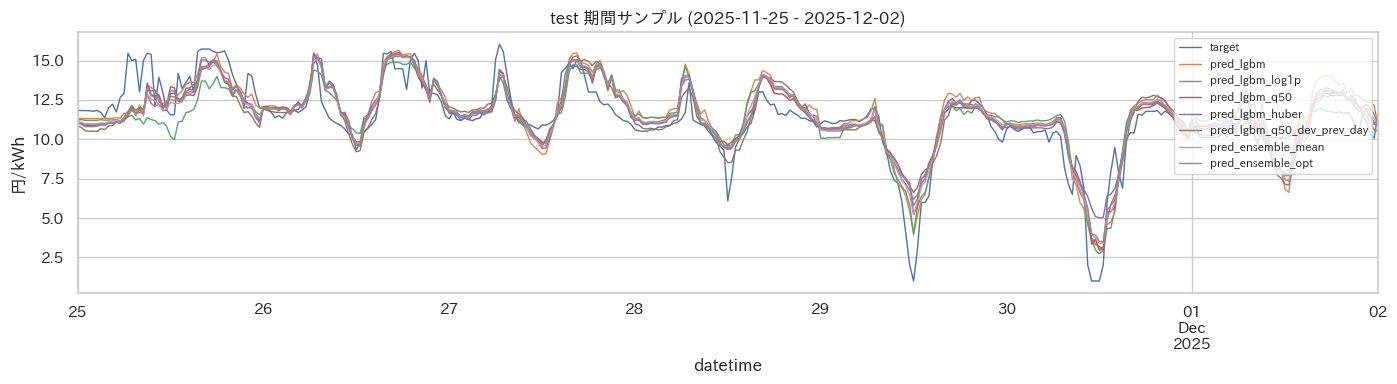

In [14]:
# test 期間冒頭の 7 日分を切り出して時系列を比較
sample_start = test_df.index.min()
sample_end = sample_start + pd.Timedelta(days=7)
sample = pd.DataFrame(
    {
        "target":                       y_test,
        "pred_lgbm":                    y_pred_lgbm_test,
        "pred_lgbm_log1p":              y_pred_lgbm_log_test,
        "pred_lgbm_q50":                y_pred_lgbm_q50_test,
        "pred_lgbm_huber":              y_pred_lgbm_huber_test,
        "pred_lgbm_q50_dev_prev_day":   y_pred_lgbm_dev_test,
        "pred_ensemble_mean":           y_pred_ens_mean_test,
        "pred_ensemble_opt":            y_pred_ens_opt_test,
    }
).loc[sample_start:sample_end]

fig, ax = plt.subplots(figsize=(14, 4))
sample.plot(ax=ax, lw=1.0)
ax.set_title(f"test 期間サンプル ({sample_start.date()} - {sample_end.date()})")
ax.set_ylabel("円/kWh")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()


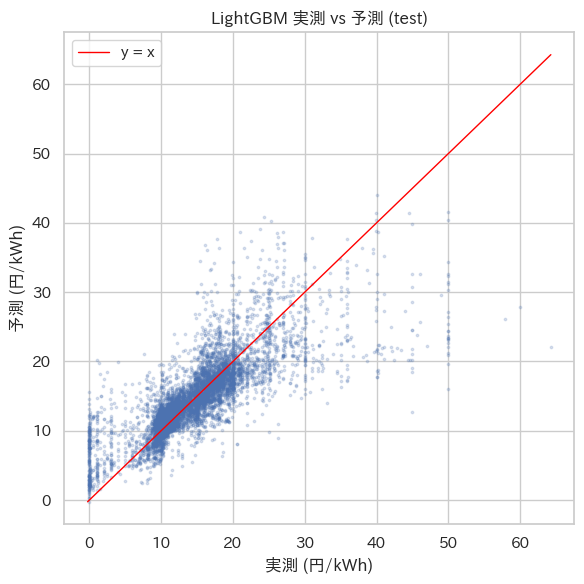

In [15]:
# 実測 vs 予測 (LightGBM)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_lgbm_test, s=3, alpha=0.2)
lo = min(y_test.min(), y_pred_lgbm_test.min())
hi = max(y_test.max(), y_pred_lgbm_test.max())
ax.plot([lo, hi], [lo, hi], color="red", lw=1, label="y = x")
ax.set_xlabel("実測 (円/kWh)")
ax.set_ylabel("予測 (円/kWh)")
ax.set_title("LightGBM 実測 vs 予測 (test)")
ax.legend()
plt.tight_layout()
plt.show()


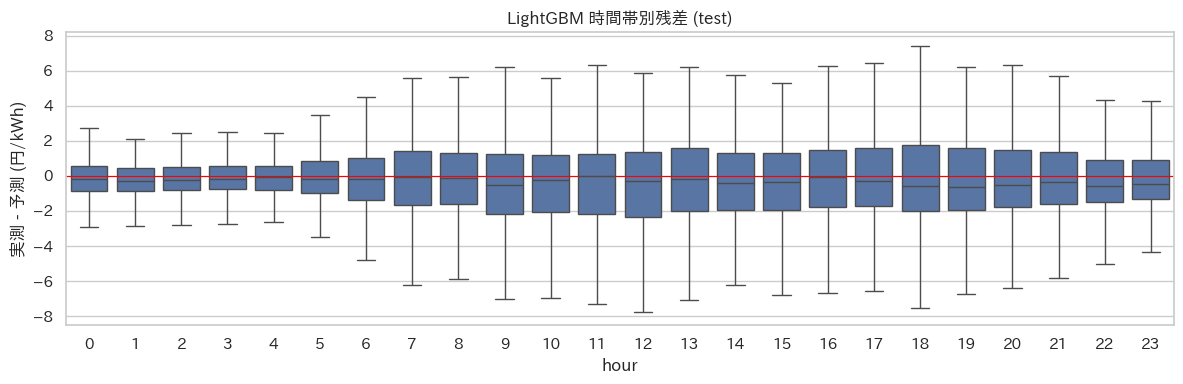

In [16]:
# 時間帯別の残差 (LightGBM)
resid = (y_test - y_pred_lgbm_test).rename("residual").to_frame()
resid["hour"] = resid.index.hour

fig, ax = plt.subplots(figsize=(12, 4))
sns.boxplot(data=resid, x="hour", y="residual", ax=ax, showfliers=False)
ax.axhline(0, color="red", lw=0.8)
ax.set_title("LightGBM 時間帯別残差 (test)")
ax.set_ylabel("実測 - 予測 (円/kWh)")
plt.tight_layout()
plt.show()


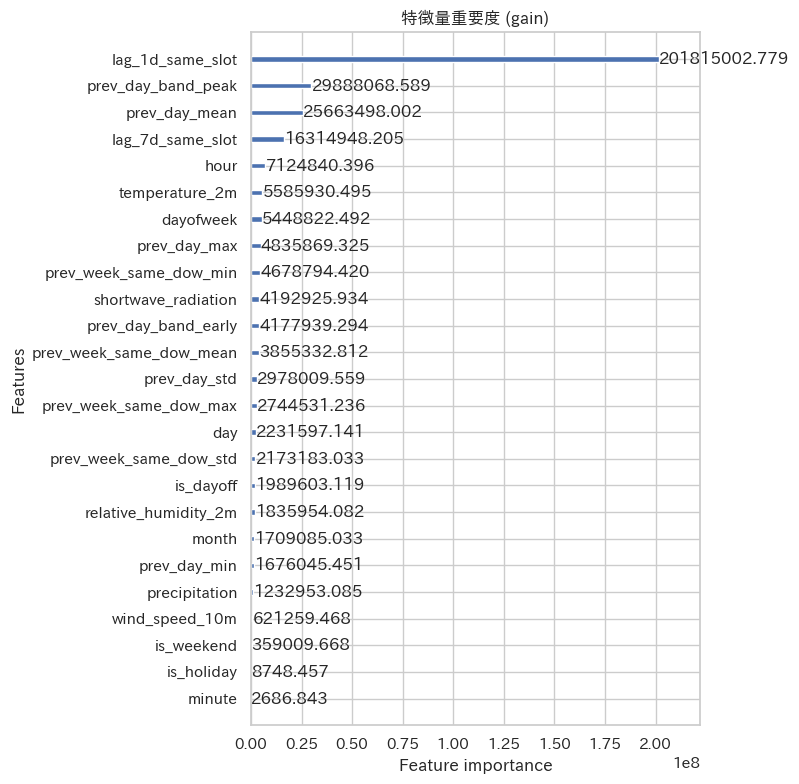

In [17]:
# 特徴量重要度 (gain)
fig, ax = plt.subplots(figsize=(8, 8))
lgb.plot_importance(lgbm_model, ax=ax, max_num_features=25, importance_type="gain", title="特徴量重要度 (gain)")
plt.tight_layout()
plt.show()


## 保存


In [18]:
artifact = {
    "lightgbm":       {"model": lgbm_model,       "params": {**LGBM_PARAMS, "seed": RANDOM_SEED},
                       "best_iteration": lgbm_model.best_iteration, "feature_cols": feature_cols},
    "lightgbm_log1p": {"model": lgbm_model_log,   "params": {**LGBM_PARAMS, "seed": RANDOM_SEED},
                       "best_iteration": lgbm_model_log.best_iteration, "target_offset": TARGET_OFFSET,
                       "feature_cols": feature_cols},
    "lightgbm_q50":   {"model": lgbm_model_q50,   "params": lgbm_q50_params,
                       "best_iteration": lgbm_model_q50.best_iteration, "feature_cols": feature_cols},
    "lightgbm_huber": {"model": lgbm_model_huber, "params": lgbm_huber_params,
                       "best_iteration": lgbm_model_huber.best_iteration, "feature_cols": feature_cols},
    "lightgbm_q50_dev_prev_day": {
        "model": lgbm_model_dev,
        "params": lgbm_dev_params,
        "best_iteration": lgbm_model_dev.best_iteration,
        "feature_cols": feature_cols,
        "inverse_ref_col": "prev_day_mean",
        "is_main": True,
    },
    "ensemble": {
        "model_order": model_names,
        "weights_mean": w_mean.tolist(),
        "weights_opt":  w_opt.tolist(),
    },
    "split": {
        "test_months": TEST_MONTHS, "val_months": VAL_MONTHS,
        "train_end": str(train_df.index.max()),
        "val_end":   str(val_df.index.max()),
        "test_end":  str(test_df.index.max()),
    },
}
joblib.dump(artifact, MODEL_PATH)

predictions_test = pd.DataFrame(
    {
        "target":                      y_test,
        "pred_naive7":                 y_pred_naive_test,
        "pred_lgbm":                   y_pred_lgbm_test,
        "pred_lgbm_log1p":             y_pred_lgbm_log_test,
        "pred_lgbm_q50":               y_pred_lgbm_q50_test,
        "pred_lgbm_huber":             y_pred_lgbm_huber_test,
        "pred_lgbm_q50_dev_prev_day":  y_pred_lgbm_dev_test,
        "pred_ensemble_mean":          y_pred_ens_mean_test,
        "pred_ensemble_opt":           y_pred_ens_opt_test,
    }
)
predictions_test.to_parquet(PRED_PATH)
metrics_df.reset_index().to_csv(METRICS_PATH, index=False)

print("saved model   :", MODEL_PATH)
print("saved preds   :", PRED_PATH)
print("saved metrics :", METRICS_PATH)

# 再ロード検証 (新メインモデル)
reloaded = joblib.load(MODEL_PATH)
probe_offset = reloaded["lightgbm_q50_dev_prev_day"]["model"].predict(
    X_test.head(10), num_iteration=reloaded["lightgbm_q50_dev_prev_day"]["best_iteration"]
)
probe_raw = probe_offset + test_df["prev_day_mean"].head(10).values
print("reload probe (dev_prev_day + offset → raw):", probe_raw)


saved model   : /home/kohei/WorkSpace/blog/06.JEPX_estimation/data/model_lgbm.joblib
saved preds   : /home/kohei/WorkSpace/blog/06.JEPX_estimation/data/predictions_test.parquet
saved metrics : /home/kohei/WorkSpace/blog/06.JEPX_estimation/data/metrics_summary.csv
reload probe (dev_prev_day + offset → raw): [10.85302434 10.73879831 10.53571035 10.5042261  10.52259099 10.49209016
 10.6813316  10.61784457 10.85029545 10.87436143]
